# S-QIDS Validation Experiment V1
## Selective Quantum-Based Intrusion Detection System

**Purpose:** Validate whether a quantum kernel classifier can complement a strong LightGBM IDS specifically on difficult / low-confidence network observations, while reducing quantum workload through selective routing.

### Core research questions
1. Does the quantum branch correct a meaningful subset of LightGBM errors?
2. Are quantum corrections concentrated in low-confidence classical predictions?
3. Can selective quantum routing preserve or improve F1/MCC with much lower quantum utilization?
4. Is uncertainty-guided routing better than random routing under the same quantum budget?

### Dataset
UNSW-NB15 binary classification using:
- `UNSW_NB15_training-set.csv`
- `UNSW_NB15_testing-set.csv`

### Main outputs
- `sample_level_predictions.csv`
- `error_overlap.csv`
- `routing_results.csv`
- `budget_matched_routing.csv`
- `quantum_correction_analysis.csv`
- `sqids_summary.csv`
- `feature_importance.csv`
- `SQIDS_Validation_V1_Results.zip`

> This V1 notebook intentionally uses a fixed fidelity quantum kernel. The next version can replace it with repaired QKA and uncertainty-guided quantum training after the selective-routing hypothesis is validated.

In [1]:
# ============================================================
# Cell 1 - Install Dependencies
# ============================================================

!pip -q install \
    "qiskit>=2.2" \
    "qiskit-machine-learning>=0.9.0" \
    "qiskit-aer>=0.17"


print("Installation complete.")
print("If Colab asks for a runtime restart because of package upgrades, restart once and continue from Cell 2.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
Installation complete.
If Colab asks for a runtime restart because of package upgrades, restart once and continue from Cell 2.


In [2]:
# ============================================================
# Cell 2 - Imports and Environment Information
# ============================================================

import os
import time
import json
import random
import warnings
import platform

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import lightgbm
import qiskit
import qiskit_machine_learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)
from sklearn.svm import SVC

from lightgbm import LGBMClassifier

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("LightGBM:", lightgbm.__version__)
print("Qiskit:", qiskit.__version__)
print("Qiskit Machine Learning:", qiskit_machine_learning.__version__)

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn: 1.6.1
LightGBM: 4.6.0
Qiskit: 2.5.2
Qiskit Machine Learning: 0.9.0


In [3]:
# ============================================================
# Cell 3 - Global Configuration
# ============================================================

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

CONFIG = {
    "target": "label",
    "drop_columns": ["id", "attack_cat"],

    # Feature pipeline
    "mi_candidates": 25,
    "selected_features": 12,

    # Quantum representation
    "n_qubits": 6,
    "feature_map_reps": 1,

    # Equal quantum training budget
    "quantum_train_per_class": 100,

    # Candidate quantum evaluations for V1
    "quantum_eval_max": 1500,

    # Selective routing thresholds
    "routing_thresholds": [
        0.50, 0.55, 0.60, 0.65, 0.70,
        0.75, 0.80, 0.85, 0.90, 0.95
    ],

    # Classical model
    "lgb_estimators": 400,

    # Output
    "output_dir": "/content/sqids_results"
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)

print(json.dumps(CONFIG, indent=2))

{
  "target": "label",
  "drop_columns": [
    "id",
    "attack_cat"
  ],
  "mi_candidates": 25,
  "selected_features": 12,
  "n_qubits": 6,
  "feature_map_reps": 1,
  "quantum_train_per_class": 100,
  "quantum_eval_max": 1500,
  "routing_thresholds": [
    0.5,
    0.55,
    0.6,
    0.65,
    0.7,
    0.75,
    0.8,
    0.85,
    0.9,
    0.95
  ],
  "lgb_estimators": 400,
  "output_dir": "/content/sqids_results"
}


In [4]:
# ============================================================
# Cell 4 - Upload UNSW-NB15 Dataset Files
# ============================================================

from google.colab import files

uploaded = files.upload()

print("\nUploaded:")
for f in uploaded.keys():
    print(" -", f)

print("\nRequired names:")
print("  UNSW_NB15_training-set.csv")
print("  UNSW_NB15_testing-set.csv")


Uploaded:

Required names:
  UNSW_NB15_training-set.csv
  UNSW_NB15_testing-set.csv


In [5]:
# ============================================================
# Cell 5 - Locate and Load UNSW-NB15
# ============================================================

from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the paths to your datasets
TRAIN_FILE = '/content/drive/MyDrive/PhD_Work/Dataset/UNSW_NB15/UNSW_NB15_training-set.csv'
TEST_FILE = '/content/drive/MyDrive/PhD_Work/Dataset/UNSW_NB15/UNSW_NB15_testing-set.csv'

#TRAIN_FILE = locate_file("UNSW_NB15_training-set.csv")
#TEST_FILE  = locate_file("UNSW_NB15_testing-set.csv")

train_raw = pd.read_csv(TRAIN_FILE)
test_raw  = pd.read_csv(TEST_FILE)

print("Training shape:", train_raw.shape)
print("Testing shape :", test_raw.shape)

display(train_raw.head())

print("\nClass distribution - Train")
print(train_raw["label"].value_counts())

print("\nClass distribution - Test")
print(test_raw["label"].value_counts())

Mounted at /content/drive
Training shape: (82332, 45)
Testing shape : (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0



Class distribution - Train
label
1    45332
0    37000
Name: count, dtype: int64

Class distribution - Test
label
1    119341
0     56000
Name: count, dtype: int64


In [6]:
# ============================================================
# Cell 6 - Input / Target Separation
# ============================================================

DROP_COLS = [c for c in CONFIG["drop_columns"] if c in train_raw.columns]

X_train_raw = train_raw.drop(columns=DROP_COLS + ["label"]).copy()
y_train = train_raw["label"].astype(int).values

X_test_raw = test_raw.drop(columns=DROP_COLS + ["label"]).copy()
y_test = test_raw["label"].astype(int).values

print("Input train:", X_train_raw.shape)
print("Input test :", X_test_raw.shape)
print("Removed:", DROP_COLS)

Input train: (82332, 42)
Input test : (175341, 42)
Removed: ['id', 'attack_cat']


In [7]:
# ============================================================
# Cell 7 - Train / Validation Split
# ============================================================

X_train_base, X_val_raw, y_train_base, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=SEED
)

print("Train:", X_train_base.shape)
print("Validation:", X_val_raw.shape)
print("Final test:", X_test_raw.shape)

Train: (65865, 42)
Validation: (16467, 42)
Final test: (175341, 42)


In [8]:
# ============================================================
# Cell 8 - Identify Feature Types
# ============================================================

categorical_cols = X_train_base.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = [
    c for c in X_train_base.columns
    if c not in categorical_cols
]

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:", len(numerical_cols))

Categorical columns:
['proto', 'service', 'state']

Numerical columns: 39


In [9]:
# ============================================================
# Cell 9 - Numerical Cleaning
# ============================================================

def clean_dataframe(df):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    return df

X_train_base = clean_dataframe(X_train_base)
X_val_raw = clean_dataframe(X_val_raw)
X_test_raw = clean_dataframe(X_test_raw)

print("Cleaning complete.")

Cleaning complete.


In [10]:
# ============================================================
# Cell 10 - Leakage-Safe Preprocessing
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_processed = preprocessor.fit_transform(X_train_base)
X_val_processed = preprocessor.transform(X_val_raw)
X_test_processed = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()

print("Processed train:", X_train_processed.shape)
print("Processed val  :", X_val_processed.shape)
print("Processed test :", X_test_processed.shape)

Processed train: (65865, 190)
Processed val  : (16467, 190)
Processed test : (175341, 190)


In [11]:
# ============================================================
# Cell 11 - Mutual Information Candidate Selection
# ============================================================

mi_scores = mutual_info_classif(
    X_train_processed,
    y_train_base,
    random_state=SEED
)

mi_df = pd.DataFrame({
    "feature": feature_names,
    "mi": mi_scores
}).sort_values("mi", ascending=False).reset_index(drop=True)

display(mi_df.head(30))

MI_K = min(CONFIG["mi_candidates"], len(mi_df))
mi_features = mi_df.head(MI_K)["feature"].tolist()

feature_name_list = list(feature_names)
mi_indices = [feature_name_list.index(f) for f in mi_features]

X_train_mi = X_train_processed[:, mi_indices]
X_val_mi = X_val_processed[:, mi_indices]
X_test_mi = X_test_processed[:, mi_indices]

print("Candidate dimensions:", X_train_mi.shape)

,feature,mi
0,sbytes,0.458202
1,smean,0.356634
2,sload,0.342358
3,dbytes,0.293506
4,ct_state_ttl,0.278855
5,rate,0.261250
6,dur,0.252145
7,dmean,0.251235
8,dttl,0.240554
9,dinpkt,0.233612


Candidate dimensions: (65865, 25)


In [12]:
# ============================================================
# Cell 12 - LightGBM Importance -> Final Top-12 Features
# ============================================================

selector_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1
)

selector_model.fit(X_train_mi, y_train_base)

importance_df = pd.DataFrame({
    "feature": mi_features,
    "importance": selector_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(importance_df)

TOP_K = min(CONFIG["selected_features"], len(importance_df))
selected_features = importance_df.head(TOP_K)["feature"].tolist()
selected_indices = [mi_features.index(f) for f in selected_features]

X_train_sel = X_train_mi[:, selected_indices]
X_val_sel = X_val_mi[:, selected_indices]
X_test_sel = X_test_mi[:, selected_indices]

print("\nSelected features:")
for i, f in enumerate(selected_features, 1):
    print(i, f)

print("\nSelected feature matrix:", X_train_sel.shape)

,feature,importance
0,sbytes,1334
1,smean,1164
2,ct_src_dport_ltm,483
3,dmean,479
4,sload,425
5,synack,424
6,ackdat,417
7,ct_dst_sport_ltm,416
8,dbytes,411
9,dur,341



Selected features:
1 sbytes
2 smean
3 ct_src_dport_ltm
4 dmean
5 sload
6 synack
7 ackdat
8 ct_dst_sport_ltm
9 dbytes
10 dur
11 tcprtt
12 rate

Selected feature matrix: (65865, 12)


In [13]:
# ============================================================
# Cell 13 - Train Full Classical LightGBM Baseline
# ============================================================

classical_model = LGBMClassifier(
    n_estimators=CONFIG["lgb_estimators"],
    learning_rate=0.04,
    num_leaves=31,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1
)

start = time.time()
classical_model.fit(X_train_sel, y_train_base)
classical_train_time = time.time() - start

p_val_c = classical_model.predict_proba(X_val_sel)[:, 1]
p_test_c = classical_model.predict_proba(X_test_sel)[:, 1]

pred_val_c = (p_val_c >= 0.5).astype(int)
pred_test_c = (p_test_c >= 0.5).astype(int)

print("LightGBM training time:", round(classical_train_time, 3), "seconds")

LightGBM training time: 2.609 seconds


In [14]:
# ============================================================
# Cell 14 - Evaluation Utilities
# ============================================================

def safe_auc(metric_fn, y_true, prob):
    try:
        return metric_fn(y_true, prob)
    except Exception:
        return np.nan

def binary_metrics(y_true, pred, prob):
    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "mcc": matthews_corrcoef(y_true, pred),
        "roc_auc": safe_auc(roc_auc_score, y_true, prob),
        "pr_auc": safe_auc(average_precision_score, y_true, prob),
    }

baseline_metrics = binary_metrics(
    y_test,
    pred_test_c,
    p_test_c
)

print("Full LightGBM baseline")
display(pd.DataFrame([baseline_metrics]).T.rename(columns={0: "LightGBM"}))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, pred_test_c))

Full LightGBM baseline


,LightGBM
accuracy,0.901723
precision,0.982315
recall,0.871293
f1,0.923479
balanced_accuracy,0.918932
mcc,0.798649
roc_auc,0.984390
pr_auc,0.992327



Confusion matrix:
[[ 54128   1872]
 [ 15360 103981]]


In [15]:
# ============================================================
# Cell 15 - Classical Confidence
# ============================================================

confidence_val = np.maximum(p_val_c, 1 - p_val_c)
confidence_test = np.maximum(p_test_c, 1 - p_test_c)

val_error = (pred_val_c != y_val).astype(int)
test_error = (pred_test_c != y_test).astype(int)

print("Mean confidence - correct:", confidence_test[test_error == 0].mean())
print("Mean confidence - errors :", confidence_test[test_error == 1].mean())
print("Classical test errors     :", test_error.sum())

Mean confidence - correct: 0.9636985682853513
Mean confidence - errors : 0.7525008508648898
Classical test errors     : 17232


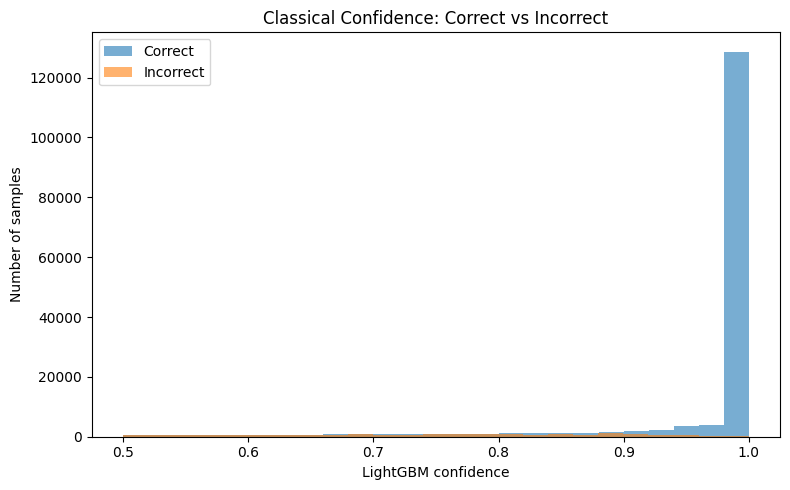

In [16]:
# ============================================================
# Cell 16 - Confidence Distribution: Correct vs Incorrect
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    confidence_test[test_error == 0],
    bins=25,
    alpha=0.6,
    label="Correct"
)
plt.hist(
    confidence_test[test_error == 1],
    bins=25,
    alpha=0.6,
    label="Incorrect"
)

plt.xlabel("LightGBM confidence")
plt.ylabel("Number of samples")
plt.title("Classical Confidence: Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# Cell 17 - Denoising Autoencoder: 12 -> 10 -> 8 -> 6
# ============================================================

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(SEED)

input_dim = X_train_sel.shape[1]

inp = Input(shape=(input_dim,))
noise = GaussianNoise(0.05)(inp)
h1 = Dense(10, activation="relu")(noise)
h2 = Dense(8, activation="relu")(h1)

latent = Dense(
    CONFIG["n_qubits"],
    activation="tanh",
    name="latent"
)(h2)

h3 = Dense(8, activation="relu")(latent)
h4 = Dense(10, activation="relu")(h3)
out = Dense(input_dim, activation="linear")(h4)

autoencoder = Model(inp, out)
encoder = Model(inp, latent)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_sel,
    X_train_sel,
    validation_data=(X_val_sel, X_val_sel),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

print("Best validation reconstruction loss:", min(history.history["val_loss"]))

Epoch 1/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 4497.5137 - val_loss: 2151.8127
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4452.9941 - val_loss: 2079.1001
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4355.1309 - val_loss: 1951.9491
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4212.5649 - val_loss: 1800.4325
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4049.3235 - val_loss: 1621.9751
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3879.0735 - val_loss: 1470.1711
Epoch 7/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3750.8459 - val_loss: 1414.3320
Epoch 8/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3801.5142 - val_loss: 1415.2948
Epoch 9/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3681.7334 - val_loss: 1317.0836
Epoch 10/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3551.6311 - val_loss: 1202.9172
Epoch 11/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3463.8

In [18]:
# ============================================================
# Cell 18 - Generate 6-D Latent Representation
# ============================================================

Z_train = encoder.predict(X_train_sel, verbose=0)
Z_val = encoder.predict(X_val_sel, verbose=0)
Z_test = encoder.predict(X_test_sel, verbose=0)

print("Latent train:", Z_train.shape)
print("Latent val  :", Z_val.shape)
print("Latent test :", Z_test.shape)

Latent train: (65865, 6)
Latent val  : (16467, 6)
Latent test : (175341, 6)


In [19]:
# ============================================================
# Cell 19 - Scale Latent Values to [0, pi]
# ============================================================

quantum_scaler = MinMaxScaler(feature_range=(0, np.pi))

Z_train_q = quantum_scaler.fit_transform(Z_train)
Z_val_q = quantum_scaler.transform(Z_val)
Z_test_q = quantum_scaler.transform(Z_test)

print("Quantum range:", Z_train_q.min(), Z_train_q.max())

Quantum range: 0.0 3.1415927


In [20]:
# ============================================================
# Cell 20 - Balanced Quantum Training Subset
# ============================================================

def balanced_subset(X, y, per_class, seed=42):
    rng = np.random.default_rng(seed)
    selected = []

    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        n = min(per_class, len(idx))
        cls_idx = rng.choice(idx, size=n, replace=False)
        selected.extend(cls_idx.tolist())

    selected = np.array(selected)
    rng.shuffle(selected)

    return X[selected], y[selected], selected

Z_q_train, y_q_train, q_train_idx = balanced_subset(
    Z_train_q,
    y_train_base,
    CONFIG["quantum_train_per_class"],
    SEED
)

print("Quantum training:", Z_q_train.shape)
print(pd.Series(y_q_train).value_counts())

Quantum training: (200, 6)
1    100
0    100
Name: count, dtype: int64


In [21]:
# ============================================================
# Cell 21 - Build 6-Qubit ZZ Feature Map
# ============================================================

N_QUBITS = CONFIG["n_qubits"]

feature_map = ZZFeatureMap(
    feature_dimension=N_QUBITS,
    reps=CONFIG["feature_map_reps"],
    entanglement="linear"
)

print(feature_map)
print("Number of qubits:", feature_map.num_qubits)
print("Circuit depth:", feature_map.depth())

     ┌──────────────────────────────────────────────┐
q_0: ┤0                                             ├
     │                                              │
q_1: ┤1                                             ├
     │                                              │
q_2: ┤2                                             ├
     │  ZZFeatureMap(x[0],x[1],x[2],x[3],x[4],x[5]) │
q_3: ┤3                                             ├
     │                                              │
q_4: ┤4                                             ├
     │                                              │
q_5: ┤5                                             ├
     └──────────────────────────────────────────────┘
Number of qubits: 6
Circuit depth: 1


In [22]:
# ============================================================
# Cell 22 - Initialize Fidelity Quantum Kernel
# ============================================================

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map,
    enforce_psd=True
)

print("Quantum kernel initialized.")

Quantum kernel initialized.


In [23]:
# ============================================================
# Cell 23 - Quantum Training Kernel Matrix
# ============================================================

start = time.time()

K_q_train = quantum_kernel.evaluate(
    x_vec=Z_q_train
)

kernel_train_time = time.time() - start

print("Kernel matrix:", K_q_train.shape)
print("Training kernel time:", round(kernel_train_time, 2), "seconds")

Kernel matrix: (200, 200)
Training kernel time: 188.59 seconds


In [24]:
# ============================================================
# Cell 24 - Train Quantum-Kernel SVC
# ============================================================

qsvc = SVC(
    kernel="precomputed",
    probability=True,
    class_weight="balanced",
    random_state=SEED
)

qsvc.fit(
    K_q_train,
    y_q_train
)

print("Quantum-kernel SVC trained.")

Quantum-kernel SVC trained.


In [25]:
# ============================================================
# Cell 25 - Candidate Samples for Quantum Validation
# ============================================================
# V1 optimization:
#   1) include all classical errors if possible
#   2) fill remaining budget with lowest-confidence samples
#
# NOTE:
# For final publication experiments, evaluate quantum predictions
# on the full held-out test set or on a prospectively selected
# routing set. This diagnostic cell intentionally enriches the
# candidate pool to study complementarity efficiently.

n_test = len(y_test)

error_indices = np.where(pred_test_c != y_test)[0]
low_conf_order = np.argsort(confidence_test)

max_eval = min(CONFIG["quantum_eval_max"], n_test)

candidate = set()

# If classical errors exceed max_eval, retain the lowest-confidence
# errors first so the quantum budget stays bounded.
error_sorted = error_indices[np.argsort(confidence_test[error_indices])]
for idx in error_sorted:
    if len(candidate) >= max_eval:
        break
    candidate.add(int(idx))

for idx in low_conf_order:
    if len(candidate) >= max_eval:
        break
    candidate.add(int(idx))

candidate_idx = np.array(sorted(candidate))

print("Classical errors:", len(error_indices))
print("Quantum validation candidates:", len(candidate_idx))
print("Candidate fraction of test set:", round(len(candidate_idx) / len(y_test), 4))

Classical errors: 17232
Quantum validation candidates: 1500
Candidate fraction of test set: 0.0086


In [27]:
# ============================================================
# Cell 26 - Evaluate Quantum Branch on Candidate Observations
# ============================================================

Z_test_candidate = Z_test_q[candidate_idx]

start = time.time()

K_q_test = quantum_kernel.evaluate(
    x_vec=Z_test_candidate,
    y_vec=Z_q_train
)

quantum_eval_time = time.time() - start

p_q_candidate = qsvc.predict_proba(K_q_test)[:, 1]
pred_q_candidate = (p_q_candidate >= 0.5).astype(int)

print("Quantum evaluation time:", round(quantum_eval_time, 2), "seconds")
print("Test kernel shape:", K_q_test.shape)

Quantum evaluation time: 2970.85 seconds
Test kernel shape: (1500, 200)


In [28]:
# ============================================================
# Cell 27 - Sample-Level Prediction Table
# ============================================================

analysis_df = pd.DataFrame({
    "test_index": candidate_idx,
    "true_label": y_test[candidate_idx],
    "classical_prob": p_test_c[candidate_idx],
    "classical_pred": pred_test_c[candidate_idx],
    "classical_confidence": confidence_test[candidate_idx],
    "quantum_prob": p_q_candidate,
    "quantum_pred": pred_q_candidate
})

analysis_df["classical_correct"] = (
    analysis_df["classical_pred"] == analysis_df["true_label"]
)

analysis_df["quantum_correct"] = (
    analysis_df["quantum_pred"] == analysis_df["true_label"]
)

analysis_df["quantum_corrected_classical"] = (
    (~analysis_df["classical_correct"]) &
    analysis_df["quantum_correct"]
)

analysis_df["quantum_broke_classical"] = (
    analysis_df["classical_correct"] &
    (~analysis_df["quantum_correct"])
)

display(analysis_df.head(20))

,test_index,true_label,classical_prob,classical_pred,classical_confidence,quantum_prob,quantum_pred,classical_correct,quantum_correct,quantum_corrected_classical,quantum_broke_classical
0,41,0,0.526952,1,0.526952,0.543881,1,False,False,False,False
1,95,0,0.512618,1,0.512618,0.541610,1,False,False,False,False
2,101,0,0.534179,1,0.534179,0.486494,0,False,True,True,False
3,174,0,0.526788,1,0.526788,0.544061,1,False,False,False,False
4,5105,0,0.515014,1,0.515014,0.545648,1,False,False,False,False
5,5110,0,0.515014,1,0.515014,0.545624,1,False,False,False,False
6,5510,0,0.516106,1,0.516106,0.551053,1,False,False,False,False
7,5791,0,0.508494,1,0.508494,0.546914,1,False,False,False,False
8,6954,0,0.511613,1,0.511613,0.547771,1,False,False,False,False
9,7155,0,0.501693,1,0.501693,0.547778,1,False,False,False,False


In [29]:
# ============================================================
# Cell 28 - Classical / Quantum Error Complementarity
# ============================================================

both_correct = np.sum(
    analysis_df["classical_correct"] &
    analysis_df["quantum_correct"]
)

both_wrong = np.sum(
    (~analysis_df["classical_correct"]) &
    (~analysis_df["quantum_correct"])
)

classical_only_correct = np.sum(
    analysis_df["classical_correct"] &
    (~analysis_df["quantum_correct"])
)

quantum_only_correct = np.sum(
    (~analysis_df["classical_correct"]) &
    analysis_df["quantum_correct"]
)

overlap_df = pd.DataFrame([{
    "both_correct": both_correct,
    "both_wrong": both_wrong,
    "classical_only_correct": classical_only_correct,
    "quantum_only_correct": quantum_only_correct
}])

display(overlap_df)

,both_correct,both_wrong,classical_only_correct,quantum_only_correct
0,0,444,0,1056


In [30]:
# ============================================================
# Cell 29 - Proposed Quantum Correction Rate (QCR)
# ============================================================
# QCR is an exploratory S-QIDS metric, not an established
# standard metric in quantum machine learning.

classical_error_mask = ~analysis_df["classical_correct"]

n_classical_errors_evaluated = classical_error_mask.sum()
n_quantum_corrections = analysis_df["quantum_corrected_classical"].sum()

QCR = (
    n_quantum_corrections / n_classical_errors_evaluated
    if n_classical_errors_evaluated > 0
    else np.nan
)

print("Classical errors evaluated:", n_classical_errors_evaluated)
print("Corrected by quantum:", n_quantum_corrections)
print("Quantum Correction Rate:", round(QCR, 4))

Classical errors evaluated: 1500
Corrected by quantum: 1056
Quantum Correction Rate: 0.704


In [31]:
# ============================================================
# Cell 30 - Where Does Quantum Help?
# ============================================================

corrected = analysis_df[
    analysis_df["quantum_corrected_classical"]
].copy()

not_corrected = analysis_df[
    (~analysis_df["classical_correct"]) &
    (~analysis_df["quantum_correct"])
].copy()

print(
    "Mean confidence of quantum-corrected errors:",
    corrected["classical_confidence"].mean()
)

print(
    "Mean confidence of errors quantum could not correct:",
    not_corrected["classical_confidence"].mean()
)

display(
    corrected.sort_values("classical_confidence").head(25)
)

Mean confidence of quantum-corrected errors: 0.5237924861106908
Mean confidence of errors quantum could not correct: 0.5245560699489571


,test_index,true_label,classical_prob,classical_pred,classical_confidence,quantum_prob,quantum_pred,classical_correct,quantum_correct,quantum_corrected_classical,quantum_broke_classical
700,83000,1,0.499938,0,0.500062,0.546146,1,False,True,True,False
307,55505,1,0.499884,0,0.500116,0.545166,1,False,True,True,False
1476,169295,1,0.499865,0,0.500135,0.542866,1,False,True,True,False
246,51631,1,0.499832,0,0.500168,0.548057,1,False,True,True,False
968,100349,1,0.499723,0,0.500277,0.551508,1,False,True,True,False
385,62101,1,0.499680,0,0.500320,0.548054,1,False,True,True,False
428,64255,1,0.499643,0,0.500357,0.548676,1,False,True,True,False
807,88846,1,0.499545,0,0.500455,0.552367,1,False,True,True,False
223,50536,1,0.499538,0,0.500462,0.551514,1,False,True,True,False
1272,126974,1,0.499530,0,0.500470,0.542504,1,False,True,True,False


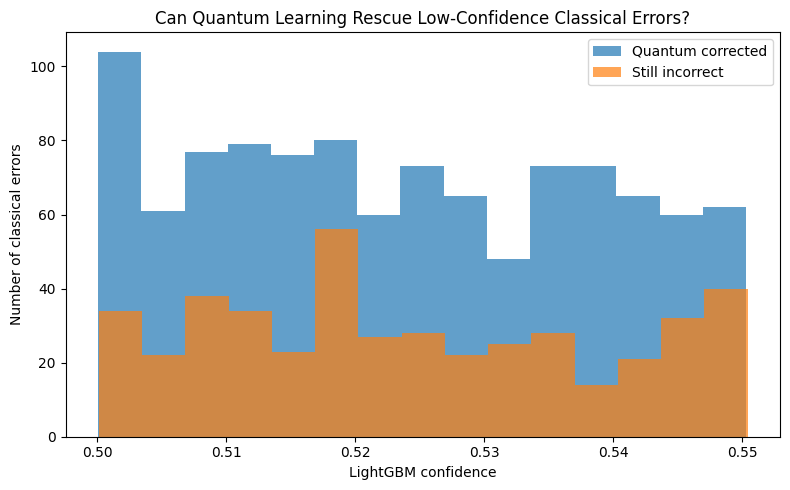

In [32]:
# ============================================================
# Cell 31 - Confidence vs Quantum Correction
# ============================================================

plt.figure(figsize=(8, 5))

if len(corrected) > 0:
    plt.hist(
        corrected["classical_confidence"],
        bins=15,
        alpha=0.7,
        label="Quantum corrected"
    )

if len(not_corrected) > 0:
    plt.hist(
        not_corrected["classical_confidence"],
        bins=15,
        alpha=0.7,
        label="Still incorrect"
    )

plt.xlabel("LightGBM confidence")
plt.ylabel("Number of classical errors")
plt.title("Can Quantum Learning Rescue Low-Confidence Classical Errors?")
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# Cell 32 - Quantum Prediction Lookup
# ============================================================

quantum_prob_lookup = dict(zip(candidate_idx.tolist(), p_q_candidate.tolist()))
quantum_pred_lookup = dict(zip(candidate_idx.tolist(), pred_q_candidate.tolist()))

print("Available quantum predictions:", len(quantum_prob_lookup))

Available quantum predictions: 1500


In [34]:
# ============================================================
# Cell 33 - Selective Quantum Routing Function
# ============================================================
# Route to quantum/hybrid refinement when:
#   classical confidence < threshold
#
# For routed samples:
#   p_final = w * p_classical + (1-w) * p_quantum
#
# Samples requested by a threshold but not present in the V1
# quantum candidate pool remain classical. The candidate_coverage
# field reports how complete that threshold simulation is.

def run_sqids_routing(threshold, fusion_weight=0.5):

    final_prob = p_test_c.copy()

    route_mask = confidence_test < threshold
    requested_indices = np.where(route_mask)[0]

    available_indices = [
        int(i) for i in requested_indices
        if int(i) in quantum_prob_lookup
    ]

    for i in available_indices:
        p_classical = p_test_c[i]
        p_quantum = quantum_prob_lookup[i]

        final_prob[i] = (
            fusion_weight * p_classical
            + (1 - fusion_weight) * p_quantum
        )

    final_pred = (final_prob >= 0.5).astype(int)

    metrics = binary_metrics(
        y_test,
        final_pred,
        final_prob
    )

    metrics["threshold"] = threshold
    metrics["quantum_routed"] = len(available_indices)
    metrics["quantum_utilization"] = len(available_indices) / len(y_test)
    metrics["requested_for_quantum"] = len(requested_indices)
    metrics["candidate_coverage"] = (
        len(available_indices) / max(1, len(requested_indices))
    )

    return metrics

In [35]:
# ============================================================
# Cell 34 - Threshold Sweep
# ============================================================

routing_results = []

for threshold in CONFIG["routing_thresholds"]:
    result = run_sqids_routing(
        threshold=threshold,
        fusion_weight=0.5
    )
    routing_results.append(result)

routing_df = pd.DataFrame(routing_results)

display(
    routing_df[
        [
            "threshold",
            "requested_for_quantum",
            "quantum_routed",
            "candidate_coverage",
            "quantum_utilization",
            "f1",
            "mcc",
            "roc_auc",
            "pr_auc"
        ]
    ]
)

,threshold,requested_for_quantum,quantum_routed,candidate_coverage,quantum_utilization,f1,mcc,roc_auc,pr_auc
0,0.50,0,0,0.000000,0.000000,0.923479,0.798649,0.984390,0.992327
1,0.55,3049,1482,0.486061,0.008452,0.927785,0.807800,0.984400,0.992332
2,0.60,6425,1500,0.233463,0.008555,0.927795,0.807820,0.984401,0.992333
3,0.65,9725,1500,0.154242,0.008555,0.927795,0.807820,0.984401,0.992333
4,0.70,13380,1500,0.112108,0.008555,0.927795,0.807820,0.984401,0.992333
5,0.75,17272,1500,0.086846,0.008555,0.927795,0.807820,0.984401,0.992333
6,0.80,21917,1500,0.068440,0.008555,0.927795,0.807820,0.984401,0.992333
7,0.85,26731,1500,0.056115,0.008555,0.927795,0.807820,0.984401,0.992333
8,0.90,32235,1500,0.046533,0.008555,0.927795,0.807820,0.984401,0.992333
9,0.95,39791,1500,0.037697,0.008555,0.927795,0.807820,0.984401,0.992333


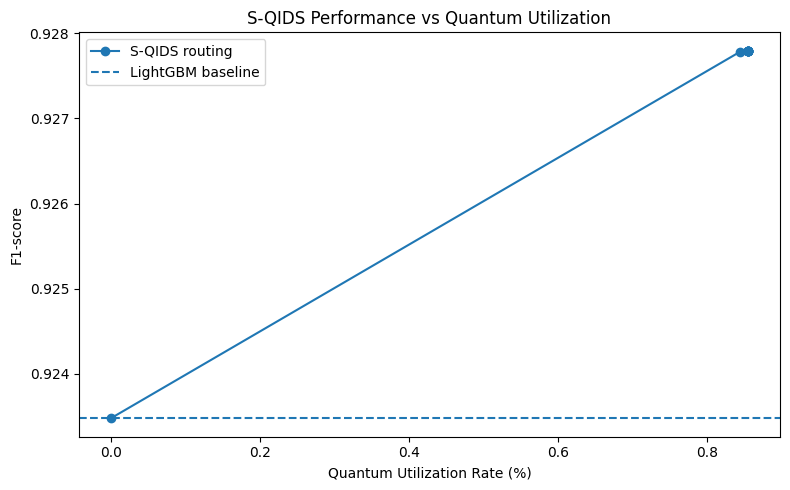

In [36]:
# ============================================================
# Cell 35 - F1 vs Quantum Utilization
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    routing_df["quantum_utilization"] * 100,
    routing_df["f1"],
    marker="o",
    label="S-QIDS routing"
)

plt.axhline(
    baseline_metrics["f1"],
    linestyle="--",
    label="LightGBM baseline"
)

plt.xlabel("Quantum Utilization Rate (%)")
plt.ylabel("F1-score")
plt.title("S-QIDS Performance vs Quantum Utilization")
plt.legend()
plt.tight_layout()
plt.show()

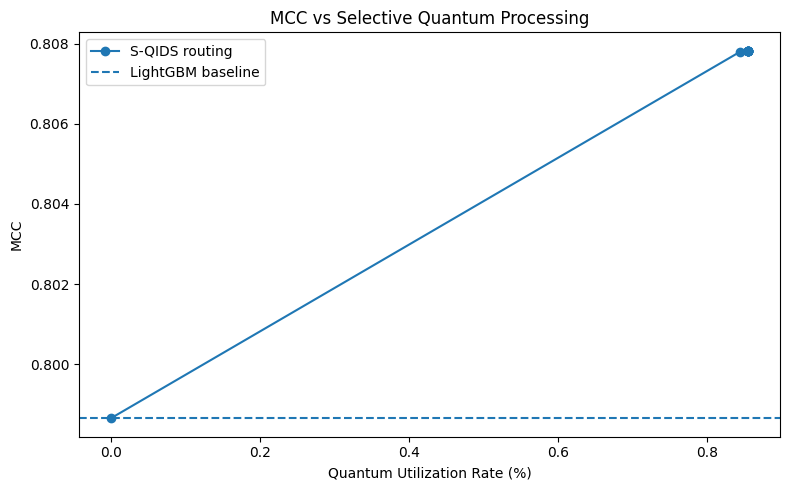

In [37]:
# ============================================================
# Cell 36 - MCC vs Quantum Utilization
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    routing_df["quantum_utilization"] * 100,
    routing_df["mcc"],
    marker="o",
    label="S-QIDS routing"
)

plt.axhline(
    baseline_metrics["mcc"],
    linestyle="--",
    label="LightGBM baseline"
)

plt.xlabel("Quantum Utilization Rate (%)")
plt.ylabel("MCC")
plt.title("MCC vs Selective Quantum Processing")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# Cell 37 - Exploratory Resource-Aware Selective Utility
# ============================================================
# This is a proposed experiment-selection score, not a standard metric.

RESOURCE_PENALTY = 0.05

routing_df["selective_utility"] = (
    routing_df["f1"]
    - RESOURCE_PENALTY * routing_df["quantum_utilization"]
)

best_idx = routing_df["selective_utility"].idxmax()
best_route = routing_df.loc[best_idx]

display(best_route.to_frame("Best selective configuration"))

,Best selective configuration
accuracy,0.906901
precision,0.982574
recall,0.878801
f1,0.927795
balanced_accuracy,0.922793
mcc,0.807820
roc_auc,0.984401
pr_auc,0.992333
threshold,0.600000
quantum_routed,1500.000000


In [39]:
# ============================================================
# Cell 38 - Budget-Matched Random Routing Control
# ============================================================

def random_routing_experiment(
    n_quantum,
    repetitions=30,
    fusion_weight=0.5
):
    rng = np.random.default_rng(SEED)

    available = np.array(list(quantum_prob_lookup.keys()), dtype=int)
    n_quantum = min(n_quantum, len(available))

    rows = []

    for rep in range(repetitions):
        selected = rng.choice(
            available,
            size=n_quantum,
            replace=False
        )

        final_prob = p_test_c.copy()

        for i in selected:
            final_prob[i] = (
                fusion_weight * p_test_c[i]
                + (1 - fusion_weight) * quantum_prob_lookup[int(i)]
            )

        final_pred = (final_prob >= 0.5).astype(int)

        metrics = binary_metrics(
            y_test,
            final_pred,
            final_prob
        )
        metrics["rep"] = rep
        rows.append(metrics)

    return pd.DataFrame(rows)

In [40]:
# ============================================================
# Cell 39 - Uncertainty Routing vs Random Routing
# ============================================================

comparison_rows = []

for _, row in routing_df.iterrows():
    n_q = int(row["quantum_routed"])

    if n_q == 0:
        continue

    random_df = random_routing_experiment(
        n_quantum=n_q,
        repetitions=30
    )

    comparison_rows.append({
        "threshold": row["threshold"],
        "quantum_routed": n_q,
        "QUR": row["quantum_utilization"],
        "candidate_coverage": row["candidate_coverage"],
        "uncertainty_f1": row["f1"],
        "random_f1_mean": random_df["f1"].mean(),
        "random_f1_std": random_df["f1"].std(),
        "uncertainty_mcc": row["mcc"],
        "random_mcc_mean": random_df["mcc"].mean(),
        "random_mcc_std": random_df["mcc"].std(),
    })

budget_comparison_df = pd.DataFrame(comparison_rows)

display(budget_comparison_df)

,threshold,quantum_routed,QUR,candidate_coverage,uncertainty_f1,random_f1_mean,random_f1_std,uncertainty_mcc,random_mcc_mean,random_mcc_std
0,0.55,1482,0.008452,0.486061,0.927785,0.927746,7.667702e-06,0.80780,0.807715,1.594496e-05
1,0.60,1500,0.008555,0.233463,0.927795,0.927795,6.775215e-16,0.80782,0.807820,5.646013e-16
2,0.65,1500,0.008555,0.154242,0.927795,0.927795,6.775215e-16,0.80782,0.807820,5.646013e-16
3,0.70,1500,0.008555,0.112108,0.927795,0.927795,6.775215e-16,0.80782,0.807820,5.646013e-16
4,0.75,1500,0.008555,0.086846,0.927795,0.927795,6.775215e-16,0.80782,0.807820,5.646013e-16
5,0.80,1500,0.008555,0.068440,0.927795,0.927795,6.775215e-16,0.80782,0.807820,5.646013e-16
6,0.85,1500,0.008555,0.056115,0.927795,0.927795,6.775215e-16,0.80782,0.807820,5.646013e-16
7,0.90,1500,0.008555,0.046533,0.927795,0.927795,6.775215e-16,0.80782,0.807820,5.646013e-16
8,0.95,1500,0.008555,0.037697,0.927795,0.927795,6.775215e-16,0.80782,0.807820,5.646013e-16


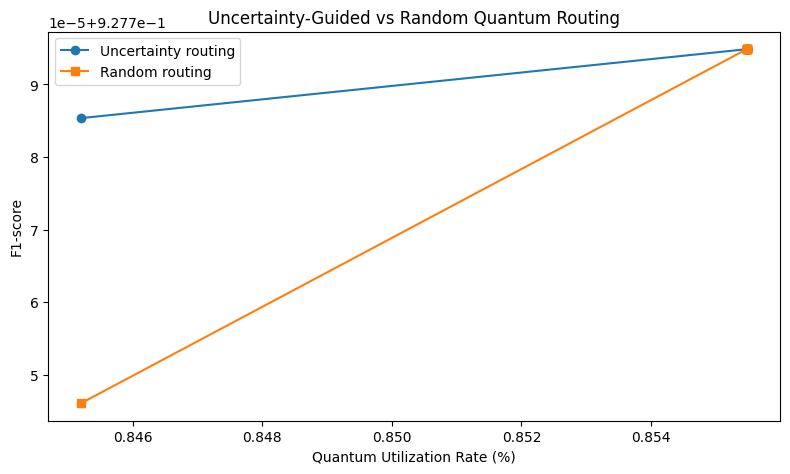

In [41]:
# ============================================================
# Cell 40 - Routing Strategy Comparison Plot
# ============================================================

if len(budget_comparison_df) > 0:
    plt.figure(figsize=(8, 5))

    plt.plot(
        budget_comparison_df["QUR"] * 100,
        budget_comparison_df["uncertainty_f1"],
        marker="o",
        label="Uncertainty routing"
    )

    plt.plot(
        budget_comparison_df["QUR"] * 100,
        budget_comparison_df["random_f1_mean"],
        marker="s",
        label="Random routing"
    )

    plt.xlabel("Quantum Utilization Rate (%)")
    plt.ylabel("F1-score")
    plt.title("Uncertainty-Guided vs Random Quantum Routing")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No routed observations were available for comparison.")

In [42]:
# ============================================================
# Cell 41 - Difficult-Sample Evaluation
# ============================================================

HARD_THRESHOLD = 0.70

hard_idx = np.where(confidence_test < HARD_THRESHOLD)[0]

hard_idx_available = np.array([
    int(i) for i in hard_idx
    if int(i) in quantum_prob_lookup
])

print("Hard samples requested:", len(hard_idx))
print("Hard samples with quantum predictions:", len(hard_idx_available))

hard_comparison = pd.DataFrame()

if len(hard_idx_available) > 0:

    y_hard = y_test[hard_idx_available]
    pred_c_hard = pred_test_c[hard_idx_available]
    p_c_hard = p_test_c[hard_idx_available]

    p_q_hard = np.array([
        quantum_prob_lookup[int(i)]
        for i in hard_idx_available
    ])

    pred_q_hard = (p_q_hard >= 0.5).astype(int)

    classical_hard_metrics = binary_metrics(
        y_hard,
        pred_c_hard,
        p_c_hard
    )

    quantum_hard_metrics = binary_metrics(
        y_hard,
        pred_q_hard,
        p_q_hard
    )

    hard_comparison = pd.DataFrame({
        "LightGBM": classical_hard_metrics,
        "Quantum": quantum_hard_metrics
    })

    display(hard_comparison)

Hard samples requested: 13380
Hard samples with quantum predictions: 1500


,LightGBM,Quantum
accuracy,0.000000,0.704000
precision,0.000000,0.785392
recall,0.000000,0.867720
f1,0.000000,0.824506
balanced_accuracy,0.000000,0.455672
mcc,-1.000000,-0.111020
roc_auc,0.000000,0.482303
pr_auc,0.600798,0.809711


In [43]:
# ============================================================
# Cell 42 - McNemar Complementarity Test
# ============================================================

from statsmodels.stats.contingency_tables import mcnemar

# Standard paired correctness contingency:
#                 Quantum correct   Quantum wrong
# Classical correct    a                b
# Classical wrong      c                d

a = both_correct
b = classical_only_correct
c = quantum_only_correct
d = both_wrong

table = [[a, b], [c, d]]

result = mcnemar(
    table,
    exact=True
)

print("McNemar table:")
print(np.array(table))
print("Statistic:", result.statistic)
print("p-value:", result.pvalue)

McNemar table:
[[   0    0]
 [1056  444]]
Statistic: 0.0
p-value: 2.590327e-318


In [44]:
# ============================================================
# Cell 43 - Quantum Correction by Confidence Region
# ============================================================

bins = [
    0.50, 0.55, 0.60, 0.65, 0.70,
    0.75, 0.80, 0.85, 0.90, 0.95, 1.01
]

analysis_df["confidence_bin"] = pd.cut(
    analysis_df["classical_confidence"],
    bins=bins,
    right=False
)

error_only = analysis_df[
    ~analysis_df["classical_correct"]
].copy()

correction_by_confidence = (
    error_only
    .groupby("confidence_bin", observed=False)
    .agg(
        classical_errors=("classical_correct", "size"),
        quantum_corrected=("quantum_corrected_classical", "sum")
    )
    .reset_index()
)

correction_by_confidence["QCR"] = (
    correction_by_confidence["quantum_corrected"]
    / correction_by_confidence["classical_errors"].replace(0, np.nan)
)

display(correction_by_confidence)

,confidence_bin,classical_errors,quantum_corrected,QCR
0,"[0.5, 0.55)",1482,1051,0.709177
1,"[0.55, 0.6)",18,5,0.277778
2,"[0.6, 0.65)",0,0,NaN
3,"[0.65, 0.7)",0,0,NaN
4,"[0.7, 0.75)",0,0,NaN
5,"[0.75, 0.8)",0,0,NaN
6,"[0.8, 0.85)",0,0,NaN
7,"[0.85, 0.9)",0,0,NaN
8,"[0.9, 0.95)",0,0,NaN
9,"[0.95, 1.01)",0,0,NaN


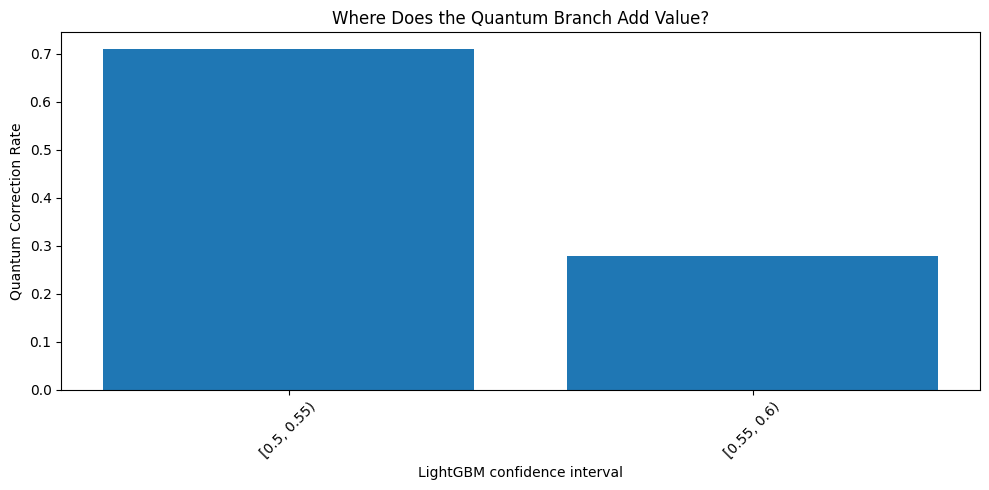

In [45]:
# ============================================================
# Cell 44 - QCR by Confidence Region Plot
# ============================================================

plot_df = correction_by_confidence.dropna(subset=["QCR"])

plt.figure(figsize=(10, 5))

plt.bar(
    plot_df["confidence_bin"].astype(str),
    plot_df["QCR"]
)

plt.xticks(rotation=45)
plt.xlabel("LightGBM confidence interval")
plt.ylabel("Quantum Correction Rate")
plt.title("Where Does the Quantum Branch Add Value?")
plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# Cell 45 - Approximate Quantum Workload Analysis
# ============================================================

N_Q_TRAIN = len(Z_q_train)

routing_df["approx_test_kernel_pairs"] = (
    routing_df["quantum_routed"] * N_Q_TRAIN
)

full_quantum_pairs = len(y_test) * N_Q_TRAIN

routing_df["kernel_work_reduction"] = (
    1
    - routing_df["approx_test_kernel_pairs"] / full_quantum_pairs
)

display(
    routing_df[
        [
            "threshold",
            "quantum_utilization",
            "f1",
            "approx_test_kernel_pairs",
            "kernel_work_reduction",
            "candidate_coverage"
        ]
    ]
)

,threshold,quantum_utilization,f1,approx_test_kernel_pairs,kernel_work_reduction,candidate_coverage
0,0.50,0.000000,0.923479,0,1.000000,0.000000
1,0.55,0.008452,0.927785,296400,0.991548,0.486061
2,0.60,0.008555,0.927795,300000,0.991445,0.233463
3,0.65,0.008555,0.927795,300000,0.991445,0.154242
4,0.70,0.008555,0.927795,300000,0.991445,0.112108
5,0.75,0.008555,0.927795,300000,0.991445,0.086846
6,0.80,0.008555,0.927795,300000,0.991445,0.068440
7,0.85,0.008555,0.927795,300000,0.991445,0.056115
8,0.90,0.008555,0.927795,300000,0.991445,0.046533
9,0.95,0.008555,0.927795,300000,0.991445,0.037697


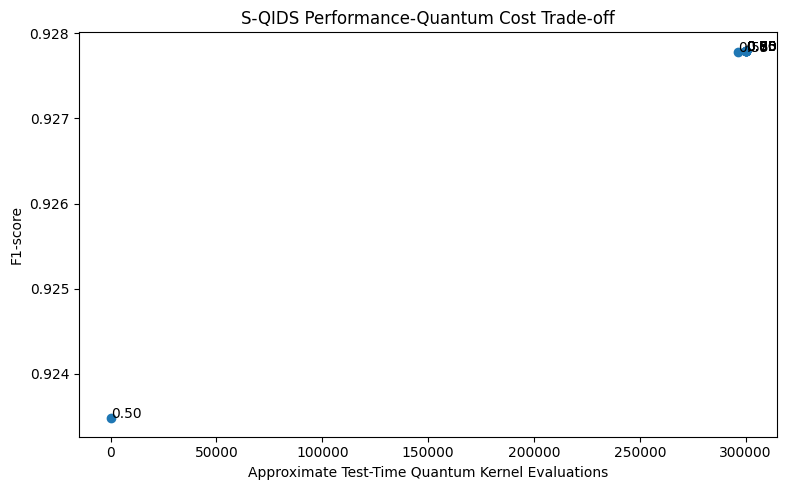

In [47]:
# ============================================================
# Cell 46 - Performance / Quantum-Cost Trade-off Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    routing_df["approx_test_kernel_pairs"],
    routing_df["f1"]
)

for _, r in routing_df.iterrows():
    plt.annotate(
        f'{r["threshold"]:.2f}',
        (
            r["approx_test_kernel_pairs"],
            r["f1"]
        )
    )

plt.xlabel("Approximate Test-Time Quantum Kernel Evaluations")
plt.ylabel("F1-score")
plt.title("S-QIDS Performance-Quantum Cost Trade-off")
plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# Cell 47 - Core S-QIDS Findings
# ============================================================

best_f1_idx = routing_df["f1"].idxmax()
best_f1_row = routing_df.loc[best_f1_idx]

summary = {
    "classical_baseline_f1": float(baseline_metrics["f1"]),
    "classical_baseline_mcc": float(baseline_metrics["mcc"]),
    "classical_baseline_roc_auc": float(baseline_metrics["roc_auc"]),
    "classical_baseline_pr_auc": float(baseline_metrics["pr_auc"]),
    "classical_test_errors": int(np.sum(pred_test_c != y_test)),
    "quantum_candidate_samples": int(len(candidate_idx)),
    "quantum_corrections": int(n_quantum_corrections),
    "quantum_correction_rate": None if np.isnan(QCR) else float(QCR),
    "best_threshold": float(best_f1_row["threshold"]),
    "best_sqids_f1": float(best_f1_row["f1"]),
    "best_sqids_mcc": float(best_f1_row["mcc"]),
    "best_sqids_QUR": float(best_f1_row["quantum_utilization"]),
    "best_candidate_coverage": float(best_f1_row["candidate_coverage"]),
    "best_kernel_reduction": float(best_f1_row["kernel_work_reduction"]),
    "classical_training_time_sec": float(classical_train_time),
    "quantum_train_kernel_time_sec": float(kernel_train_time),
    "quantum_candidate_eval_time_sec": float(quantum_eval_time),
}

print(json.dumps(summary, indent=2))

{
  "classical_baseline_f1": 0.9234793111717008,
  "classical_baseline_mcc": 0.7986494688370309,
  "classical_baseline_roc_auc": 0.984390150538014,
  "classical_baseline_pr_auc": 0.9923271072664747,
  "classical_test_errors": 17232,
  "quantum_candidate_samples": 1500,
  "quantum_corrections": 1056,
  "quantum_correction_rate": 0.704,
  "best_threshold": 0.6,
  "best_sqids_f1": 0.9277948318721857,
  "best_sqids_mcc": 0.8078204215018223,
  "best_sqids_QUR": 0.00855475901243862,
  "best_candidate_coverage": 0.23346303501945526,
  "best_kernel_reduction": 0.9914452409875614,
  "classical_training_time_sec": 2.609163284301758,
  "quantum_train_kernel_time_sec": 188.58769845962524,
  "quantum_candidate_eval_time_sec": 2970.8540346622467
}


In [49]:
# ============================================================
# Cell 48 - Export Publication Data
# ============================================================

OUT = CONFIG["output_dir"]
os.makedirs(OUT, exist_ok=True)

analysis_df.to_csv(
    f"{OUT}/sample_level_predictions.csv",
    index=False
)

overlap_df.to_csv(
    f"{OUT}/error_overlap.csv",
    index=False
)

routing_df.to_csv(
    f"{OUT}/routing_results.csv",
    index=False
)

budget_comparison_df.to_csv(
    f"{OUT}/budget_matched_routing.csv",
    index=False
)

correction_by_confidence.to_csv(
    f"{OUT}/quantum_correction_analysis.csv",
    index=False
)

pd.DataFrame([summary]).to_csv(
    f"{OUT}/sqids_summary.csv",
    index=False
)

importance_df.to_csv(
    f"{OUT}/feature_importance.csv",
    index=False
)

mi_df.to_csv(
    f"{OUT}/mutual_information_ranking.csv",
    index=False
)

if len(hard_comparison) > 0:
    hard_comparison.to_csv(
        f"{OUT}/hard_sample_comparison.csv"
    )

with open(
    f"{OUT}/selected_features.txt",
    "w"
) as f:
    for feature in selected_features:
        f.write(feature + "\n")

with open(
    f"{OUT}/config.json",
    "w"
) as f:
    json.dump(CONFIG, f, indent=2)

print("Results saved to:", OUT)

print("\nGenerated files:")
for fn in sorted(os.listdir(OUT)):
    print(" -", fn)

Results saved to: /content/sqids_results

Generated files:
 - budget_matched_routing.csv
 - config.json
 - error_overlap.csv
 - feature_importance.csv
 - hard_sample_comparison.csv
 - mutual_information_ranking.csv
 - quantum_correction_analysis.csv
 - routing_results.csv
 - sample_level_predictions.csv
 - selected_features.txt
 - sqids_summary.csv


In [50]:
# ============================================================
# Cell 49 - Create ZIP Result Package
# ============================================================

import shutil

zip_path = shutil.make_archive(
    "/content/SQIDS_Validation_V1_Results",
    "zip",
    CONFIG["output_dir"]
)

print("Created:", zip_path)

Created: /content/SQIDS_Validation_V1_Results.zip


In [51]:
# ============================================================
# Cell 50 - Download ZIP Results
# ============================================================

from google.colab import files

files.download(
    "/content/SQIDS_Validation_V1_Results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interpreting the experiment

A strong S-QIDS validation does **not** require the quantum model to beat LightGBM globally.

Useful evidence includes any of the following:

- The quantum branch corrects a meaningful fraction of LightGBM mistakes.
- Quantum corrections occur disproportionately among low-confidence classical samples.
- Selective S-QIDS reaches similar or better F1/MCC than the classical baseline with low quantum utilization.
- Uncertainty-guided routing beats random routing at the same quantum budget.
- A large reduction in approximate quantum kernel evaluations is obtained with little loss in predictive performance.

### Important V1 limitation
For computational efficiency, the quantum candidate pool is enriched using observed classical errors plus low-confidence samples. Therefore, this notebook is primarily a **diagnostic complementarity experiment**. Before publication, the main routing experiment should be repeated using prospective routing based only on quantities available at inference time (confidence, entropy, autoencoder error, ensemble disagreement), without using true test labels to define the quantum candidate set.

### Recommended V2
After V1 succeeds:
1. replace the fixed kernel with the repaired QKA from the previous paper;
2. compare random vs uncertainty-guided vs boundary-aware quantum training subsets;
3. evaluate full prospective routing on the held-out test set;
4. add repeated seeds and statistical comparisons;
5. then add constraint-aware FGSM/PGD adversarial experiments.